In [1]:
from telescope import *
from spectrograph import *
from detector import *
from spectralmodels import Sky, get_list_of_stellar_models, get_stellar_spectrum
from etc.etc import simulate_1D_spectrum, simulate_2D_spectrum, SpecETC

import numpy as np
from matplotlib import pyplot as plt

LRIS-B-600: Reading spectrograph efficiency from /Users/jwalawender/git/SpecETC/data/LRIS-Blue/600_mirr_eff.dat
IMX183: Reading detector efficiency from /Users/jwalawender/git/SpecETC/data/SonyIMX/QE.csv
IMX533: Reading detector efficiency from /Users/jwalawender/git/SpecETC/data/SonyIMX/QE.csv


In [2]:
models = get_list_of_stellar_models(verbose=True)
sptype = 'F8V'
mag = 11
star = get_stellar_spectrum(sptype=sptype, mag=mag)
sky = Sky(seeing=3.0*u.arcsec, mag=18)

O ['O9V', 'O8III', 'O5V']
B ['B6IV', 'B0I', 'B8V', 'B2IV', 'B0V', 'B5I', 'B1-2III', 'B3V', 'B5III', 'B5-7V', 'B1V', 'B9III', 'B8I', 'B2II', 'B5II']
A ['A3V', 'A0I', 'A0V', 'A0IV', 'A5III', 'A2V', 'A5V', 'A0III', 'A4-7IV']
F ['F0-2IV', 'F5III', 'F0III', 'F5I', 'F8IV', 'F0II', 'F0I', 'F2II', 'F5V', 'F8V', 'F0V', 'F5IV', 'F2V', 'F8I']
G ['G5V', 'G2IV', 'G8I', 'G5II', 'G0V', 'G5IV', 'G2V', 'G5III', 'G8III', 'G0I', 'G8V', 'G0IV', 'G8IV', 'G0III', 'G5I']
K ['K1IV', 'K2V', 'K3IV', 'K0III', 'K3III', 'K5V', 'K3-4II', 'K4I', 'K7V', 'K2I', 'K0V', 'K0-1II', 'K0IV', 'K5III']
M ['M0V', 'M3II', 'M2I', 'M4V', 'M5V', 'M0III', 'M10III', 'M5III', 'M2V']


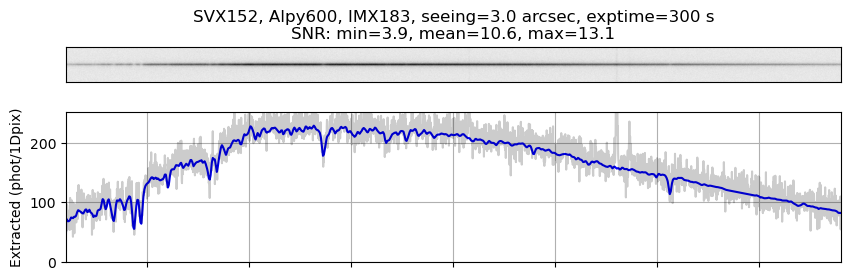

In [3]:
im, spec, var = SpecETC(star, sky, SVX152, Alpy600, IMX183, plot=True)


In [4]:
telescopes = [Newtonian12, ACF14reduced, SVX152, SVQ100]
nexp = [3, 3, 3, 3]
IMX183.exptime = 300*u.second
spectra = {}
variance = {}
for t,tel in enumerate(telescopes):
    im, spec, var = SpecETC(star, sky, tel, Alpy600, IMX183, plot=False)
    spectra[tel.name] = spec*nexp[t]
    variance[tel.name] = var*nexp[t]**0.5

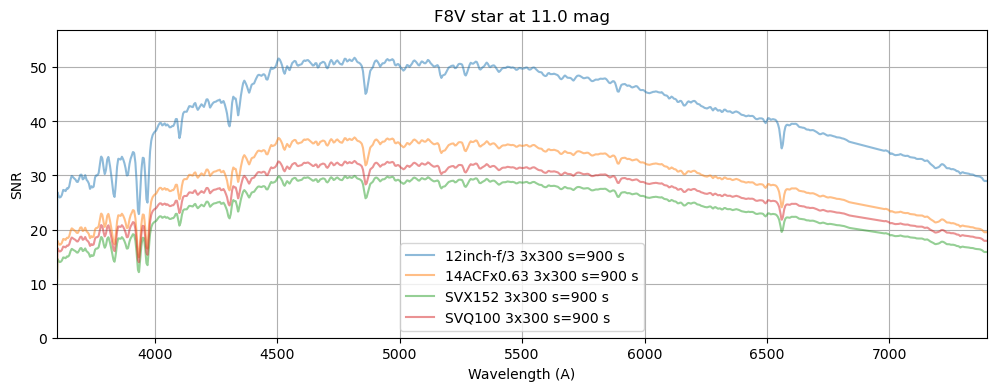

In [5]:
Alpy600.generate_binset(IMX183)
plt.figure(figsize=(12,4))
plt.title(f'{sptype} star at {mag:.1f} mag')
peakSNR = 0
for t,tel in enumerate(telescopes):
    SNR = spectra[tel.name]/variance[tel.name]**0.5
    label = f"{tel.name} {nexp[t]:d}x{IMX183.exptime:.0f}={nexp[t]*IMX183.exptime:.0f}"
    plt.plot(Alpy600.binset, SNR, alpha=0.5, label=label)
    peakSNR = peakSNR if max(SNR) <= peakSNR else max(SNR)
plt.ylabel('SNR')
plt.xlabel('Wavelength (A)')
plt.xlim(min(Alpy600.binset), max(Alpy600.binset))
plt.ylim(0,1.1*peakSNR)
plt.grid()
plt.legend(loc='best')
plt.show()

# Evaluate When Read Noise Stops Dominating

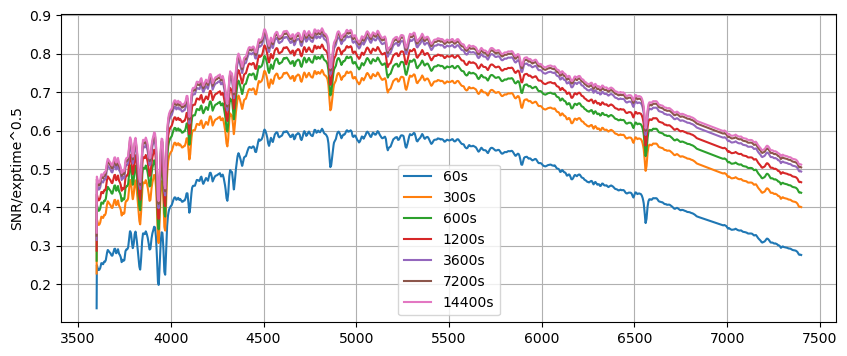

In [6]:
plt.figure(figsize=(10,4))
exptimes = [60, 300, 600, 1200, 3600, 7200, 14400]
for exptime in exptimes:
    IMX183.exptime = exptime*u.second
    im, spec, var = SpecETC(star, sky, SVX152, Alpy600, IMX183, plot=False)
    snr = spec/var**0.5
    plt.plot(Alpy600.binset, snr/exptime**0.5, label=f'{exptime}s')
plt.grid()
plt.ylabel('SNR/exptime^0.5')
plt.legend(loc='best')
plt.show()
    

# Check That Sky Brightness Matches Expectation

In [7]:
import synphot
from astropy import units as u
import numpy as np

In [8]:
# Verify Sky Brightness
Vfilter = synphot.SpectralElement.from_filter('johnson_V')
skyobs = synphot.Observation(sky.skyspec, Vfilter)
print(skyobs.countrate(1*u.cm**2))

vega = synphot.SourceSpectrum.from_vega()
vegaobs = synphot.Observation(vega, Vfilter)
print(vegaobs.countrate(1*u.cm**2))

msky = -2.5*np.log10(skyobs.countrate(1*u.cm**2)/vegaobs.countrate(1*u.cm**2))
msky

0.053789005921927355 ct / s
857771.2198307253 ct / s


<Quantity 18.00669488>